## Emma Ugarcovici

### Hwk 5 - Submission 2

In [3]:
library(tidyverse)
library(lubridate)
library(knitr)
library(fixest)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [4]:
# Data
final.hcris <- read_tsv("../../hwk4/data/input/HCRIS_Data_v2010.txt", show_col_types = FALSE)
final_data <- read_rds("../data/output/hcris_kff_combined.rds")

### Question 1: Provide a table of mean hospital uncompensated care (in millions of dollars) by year, from 2010 through 2018. How has uncompensated care changed over time?

In [5]:
q1_summary <- final.hcris %>%
  mutate(uncomp_care_val = tot_uncomp_care_charges - tot_uncomp_care_partial_pmts + bad_debt) %>%
  mutate(year = year(mdy(fy_end))) %>%
  group_by(year) %>%
  summarize(
    `uncomp care` = mean(uncomp_care_val / 1e6, na.rm = TRUE),
    `# hospitals` = n()
  ) %>%
  filter(year >= 2010 & year <= 2018) %>%
  as.data.frame()

q1_summary

year,uncomp care,# hospitals
<dbl>,<dbl>,<int>
2011,34.31733,5860
2012,37.01824,6231
2013,39.15249,6159
2014,36.36868,6168
2015,32.93677,6154
2016,44.52250,6188
2017,40.48505,6176
2018,38.03095,6158


Uncompensated care rose from 34.3M in 2011 to a peak of 39.2M in 2013 just before the major ACA expansion. After 2013, there was a notable decline through 2015, though more recent years show some volatility with a sharp spike in 2016 followed by a gradual decrease back toward 38M by 2018.

### Question 2: Plot mean uncompensated care over time separately for states that expanded Medicaid in 2014 versus states that never expanded. Drop all states that expanded after 2014. Does the graph suggest a potential treatment effect?

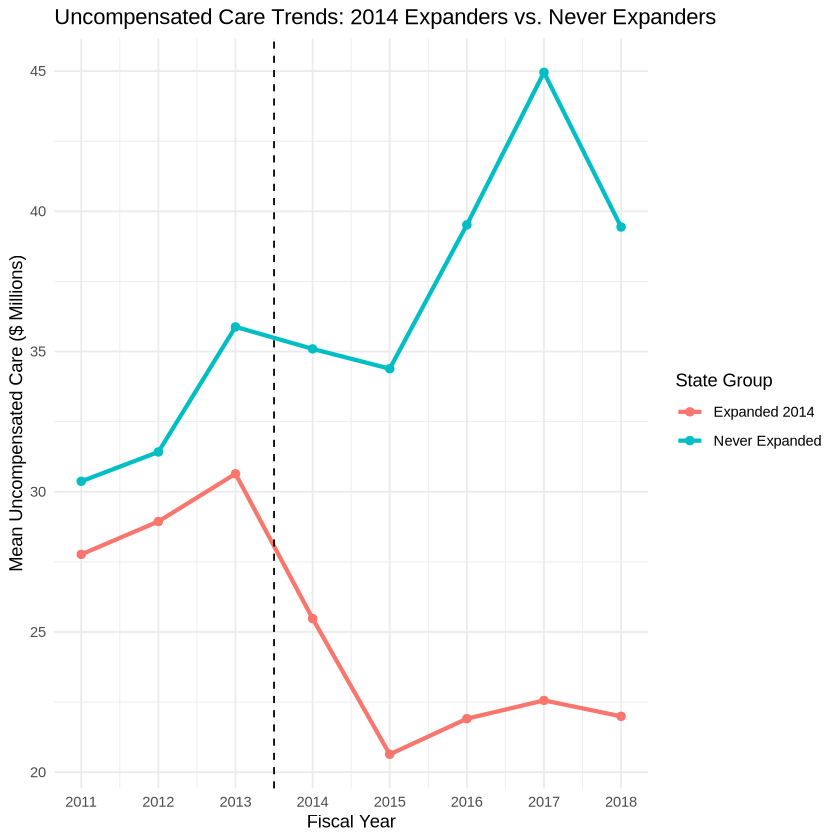

In [16]:
q2_plot_data <- final_data %>%
  filter(expansion_year == 2014 | is.na(expansion_year)) %>%
  filter(fyear >= 2010 & fyear <= 2018) %>% 
  mutate(group = ifelse(is.na(expansion_year), "Never Expanded", "Expanded 2014")) %>%
  group_by(fyear, group) %>%
  summarize(mean_uncomp = mean(uncomp_millions, na.rm = TRUE), .groups = "drop")

ggplot(q2_plot_data, aes(x = fyear, y = mean_uncomp, color = group, group = group)) +
  geom_line(linewidth = 1.2) +
  geom_point(size = 2) +
  # Vertical line positioned between 2013 and 2014
  geom_vline(xintercept = 2013.5, linetype = "dashed", color = "black") +
  scale_x_continuous(breaks = 2010:2018) +
  labs(
    title = "Uncompensated Care Trends: 2014 Expanders vs. Never Expanders",
    x = "Fiscal Year",
    y = "Mean Uncompensated Care ($ Millions)",
    color = "State Group"
  ) +
  theme_minimal()

The graph does suggest a treatment effect because the Expanded 2014 states saw a sharp, steady decrease in uncompensated care immediately following the policy change, while the Never Expanded states (which faced the same national economic conditions) saw their uncompensated care costs continue to rise.

### Question 3: Using 2012 and 2015 as your pre and post periods, present a 2x2 DD table of mean uncompensated care for expansion versus non-expansion states.

In [7]:
q3_table <- final_data %>%
  # Keep only the specific years requested
  filter(fyear %in% c(2012, 2015)) %>%
  # Filter for 2014 expanders and never-expanders
  filter(expansion_year == 2014 | is.na(expansion_year)) %>%
  # Create clean labels for groups and periods
  mutate(group = ifelse(is.na(expansion_year), "Never Expanded", "Expanded 2014"),
         period = ifelse(fyear == 2012, "Pre (2012)", "Post (2015)")) %>%
  # Calculate mean uncompensated care
  group_by(group, period) %>%
  summarize(mean_uncomp = mean(uncomp_millions, na.rm = TRUE), .groups = "drop") %>%
  pivot_wider(names_from = period, values_from = mean_uncomp) %>%
  as.data.frame()

q3_table

group,Post (2015),Pre (2012)
<chr>,<dbl>,<dbl>
Expanded 2014,20.63685,28.94020
Never Expanded,34.38708,31.41926


### Question 4: Briefly discuss what policies or events might explain the trends you observe. Why might we expect Medicaid expansion to affect uncompensated care?

The trends we see here — specifically the sharp drop in Expanded and the continued rise in Never Expanded uncompensated care costs - are mainly driven by the implementation of the Affordable Care Act (ACA) and the specific mechanisms of Medicaid Expansion. For example, the Supreme Court ruling in 2012 made expansion optional, contributing further to differences across states.

We expect a negative relationship because Medicaid acts as a financial buffer. In non-expansion states, the Never Expanded uncompensated care rises because these hospitals are still treating the same number of uninsured patients, but the cost of treating them is increasing over time due to medical inflation. In expansion states, the government takes those costs off hospital's books.

### Question 5: Estimate the effect of Medicaid expansion on hospital uncompensated care using a standard DD regression estimator, focusing only on states that expanded in 2014 versus those that never expanded.

In [9]:
# Prepare the regression data
reg_data_2x2 <- final_data %>%
  filter(fyear %in% c(2012, 2015)) %>%
  filter(expansion_year == 2014 | is.na(expansion_year)) %>%
  mutate(
    # 'treat' is 1 if they are in an expansion state
    treat = ifelse(!is.na(expansion_year), 1, 0),
    # 'post' is 1 if the year is 2015
    post = ifelse(fyear == 2015, 1, 0)
  )

# 2x2 DD model
model_q5 <- feols(uncomp_millions ~ treat + post + treat:post, data = reg_data_2x2)

model_q5

OLS estimation, Dep. Var.: uncomp_millions
Observations: 3,958
Standard-errors: IID 
             Estimate Std. Error  t value   Pr(>|t|)    
(Intercept)  31.41926    1.41767 22.16257  < 2.2e-16 ***
treat        -2.47906    1.78192 -1.39123 1.6423e-01    
post          2.96782    1.97373  1.50366 1.3275e-01    
treat:post  -11.27118    2.49249 -4.52205 6.3039e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 37.9   Adj. R2: 0.01792

### Question 6: Include hospital and year fixed effects in your estimates using the fixest package. Cluster your standard errors at the state level. How do your results compare to those in question 5?

In [12]:
reg_data_q6 <- final_data %>%
  filter(expansion_year == 2014 | is.na(expansion_year))

model_q6 <- feols(uncomp_millions ~ expand | provider_number + fyear, 
                  data = reg_data_q6, 
                  cluster = ~state)

summary(model_q6)

NOTE: 326/0 fixed-effect singletons were removed (326 observations).



OLS estimation, Dep. Var.: uncomp_millions
Observations: 18,929
Fixed-effects: provider_number: 2,730,  fyear: 13
Standard-errors: Clustered (state) 
       Estimate Std. Error  t value   Pr(>|t|)    
expand -22.4523    3.01179 -7.45479 8.3879e-09 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 16.7     Adj. R2: 0.822384
             Within R2: 0.069109

The estimated impact of Medicaid expansion nearly doubled from Q5 to Q6, (-11M to -22M). This suggests that once unique characteristics of individual hospitals are incorporated, the drop in uncompensated care is much larger than the raw averages suggested.

Also, the Adjusted $R^2$ increased from 1.8% to 82.2%. This shows that while the simple model in Q5 explained very little, the inclusion of hospital and year fixed effects in Q6 accounts for the vast majority of the variation in uncompensated care costs.

### Question 7: Repeat the analysis in question 6 but include all states (even those that expanded after 2014). Are your results different? If so, why?


In [13]:
# Estimate model using full data set
model_q7 <- feols(uncomp_millions ~ expand | provider_number + fyear, 
                  data = final_data, 
                  cluster = ~state)

summary(model_q7)

NOTE: 417/0 fixed-effect singletons were removed (417 observations).



OLS estimation, Dep. Var.: uncomp_millions
Observations: 25,629
Fixed-effects: provider_number: 3,647,  fyear: 13
Standard-errors: Clustered (state) 
       Estimate Std. Error  t value   Pr(>|t|)    
expand -16.5138    2.75423 -5.99579 2.2222e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 16.0     Adj. R2: 0.833013
             Within R2: 0.057281

The estimate dropped from -22.45 (Q6) to -16.51 (Q7). This suggests that the "early adopters" (2014 expanders) experienced a more aggressive reduction in uncompensated care than the national average. By including states that expanded later (2015-2018), the average "treatment effect" across the whole sample becomes less extreme.

### Question 8: Provide an “event study” graph showing the effects of Medicaid expansion in each year. 

NOTE: 417/0 fixed-effect singletons were removed (417 observations).



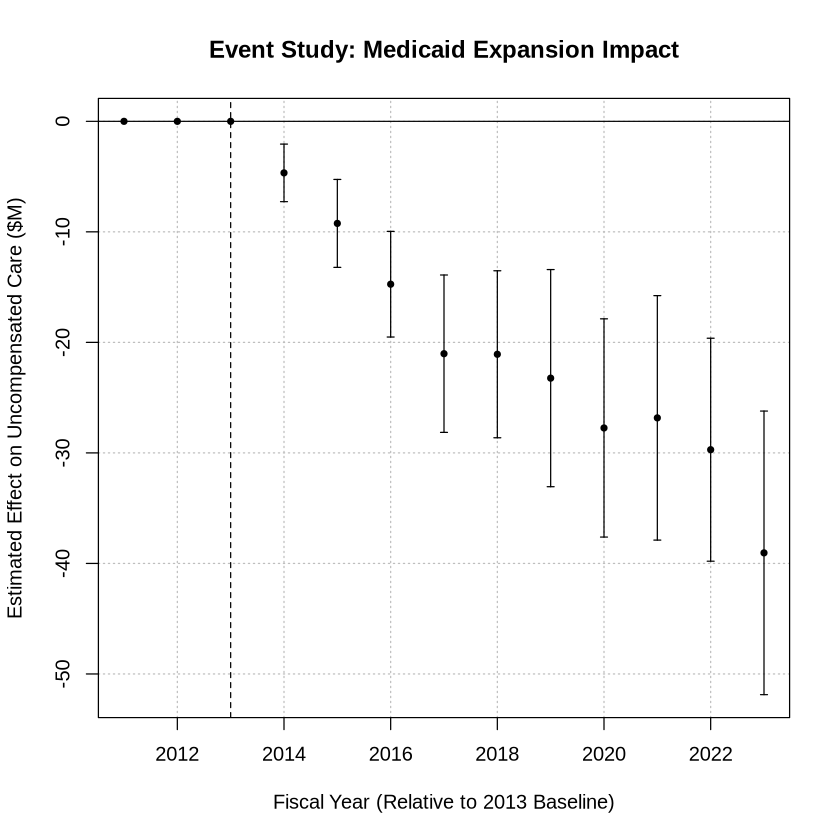

In [14]:
event_study <- feols(uncomp_millions ~ i(fyear, expand, ref = 2013) | 
                           provider_number + fyear, 
                           cluster = ~state, 
                           data = final_data)

# 2. Plot the Event Study
iplot(event_study, 
      main = "Event Study: Medicaid Expansion Impact",
      xlab = "Fiscal Year (Relative to 2013 Baseline)",
      ylab = "Estimated Effect on Uncompensated Care ($M)")

### Question 9: Repeat part 8 but include all states that expanded after 2014. You will need to construct an “event time” variable and bin end points as discussed in class.

NOTES: 7,071 observations removed because of NA values (RHS: 7,071).
       299/0 fixed-effect singletons were removed (299 observations).



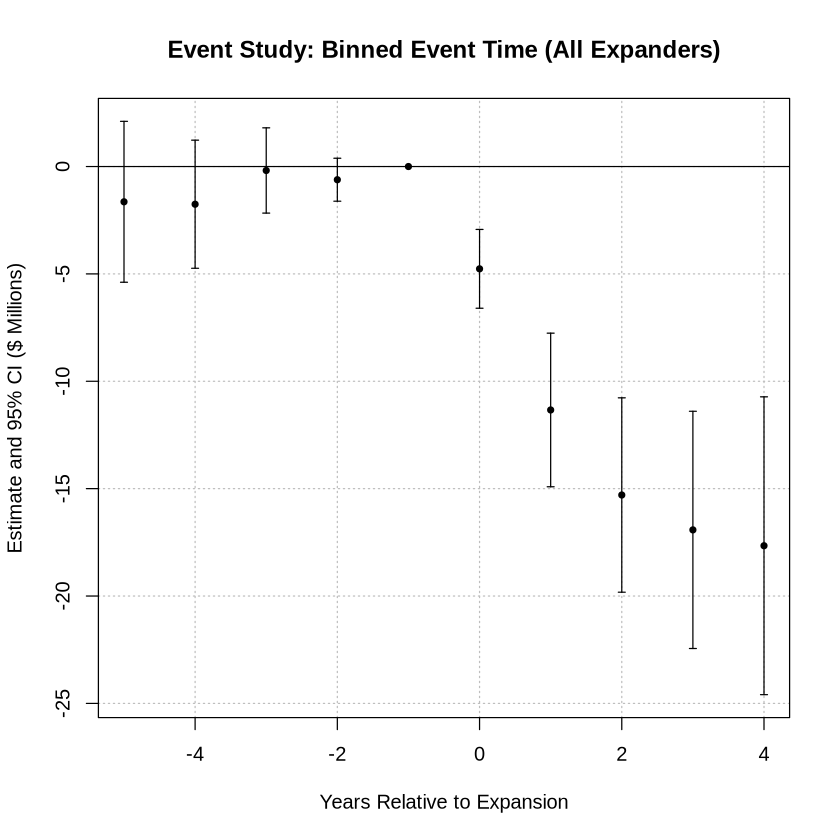

In [15]:
# Event time = Current Year - Year of Expansion
event_study_data <- final_data %>%
  mutate(
    event_time = fyear - expansion_year,
    # Bin the endpoints: -5 for anything 5+ years before, 4 for 4+ years after
    event_time_binned = case_when(
      event_time <= -5 ~ -5,
      event_time >= 4  ~ 4,
      TRUE ~ event_time
    )
  ) %>%
# Ensure the never-expanders are excluded from the 'event' interaction 
  mutate(dist_to_expansion = factor(event_time_binned))

# Estimate mode
# ref = -1 as baseline (year before expansion)
model_event_binned <- feols(uncomp_millions ~ i(event_time_binned, ref = -1) | 
                            provider_number + fyear, 
                            cluster = ~state, 
                            data = event_study_data)

iplot(model_event_binned, 
      main = "Event Study: Binned Event Time (All Expanders)",
      xlab = "Years Relative to Expansion",
      ylab = "Estimate and 95% CI ($ Millions)")

### Question 10: Summarize your findings from questions 5-9. What is the effect of Medicaid expansion on hospital uncompensated care? Do the event study graphs suggest any concerns about the parallel trends assumption? Briefly discuss one limitation of the standard TWFE estimator in the context of staggered Medicaid expansion.

- Medicaid expansion consistently reduced hospital uncompensated care costs, with estimates ranging from 16.5M to 22.5M per hospital
- Using TWFE versus DD model greatly increased the Adjusted $R^2$, showing that hospital-specific and year-to-year factors account for most of the cost variation
- Event study graphs confirm parallel trends assumption, as pre-expansion coefficients were flat and statistically insignificant, showing no divergence before the policy implementation.
- One limitation of the standard TWFE estimator is that it might underestimate the true effect due to the weighting issues that come up when comparing early-adopters to late-adopters. The TWFE estimator assumes the treatment effect is constant, but since Medicaid's impact tends to grow over time, comparing new expanders to old expanders can create a downward bias.